# Mortgage Credit Risk Analytics: A Robust Predictive Model and Macroeconomic Sensitivity Audit

**Author:** Charity Yang, Ph.D.  
**Contact:** www.linkedin.com/in/charity-yang-phd | charityyang2020@gmail.com  
**Date:** April 2026  
**Copyright:** © 2026 Charity Yang. All rights reserved.  
**License:** This work is for portfolio demonstration only. No part of this analysis, including feature engineering logic and policy recommendations, may be reproduced or used without explicit permission.

## Table of Contents

* 1. Business Problem
* 2. Data Source
* 3. Methods
* 4. Exploratory Data Analysis (EDA) & Population Overview 
* 5. Data Preprocessing
    * 5.1 Feature Engineering: Severe_Delinquency_Flag and Has_Derogatory_Marks
    * 5.2 Visualize the Distributions
    * 5.3 Working with Debt_to_Income Ratio
    * 5.4 Working with loan_to_income_ratio
    * 5.5 Working with payment_to_income_ratio
    * 5.6 Feature Engineering: high_payment_burden 
* 6. Data Analysis and Modelling
    * 6.1 Feature Selection with Visual Aids
    * 6.2 Feature Selection with IV and VIF
    * 6.3 Model Training
    * 6.4 Model Validation
    * 6.5 Test the Model with the Test Data
    * 6.6 Creating the ROC Curve
    * 6.7 Model Transparency & Sample Predictions
    * 6.8 Model Summary
    * 6.9 Sensitivity Analysis
* 7. Conclusion
* 8. Policy Recommendations


## Executive Summary

This project develops a robust analytical pipeline—encompassing exploratory data analysis (EDA), strategic feature engineering, and predictive modeling—utilizing the Realistic Loan Approval Dataset (US & Canada). The dataset contains 50,000 records across 18 predictors and a single target variable, loan_status. A structural audit confirmed 100% data integrity with no missing values or duplicate records. 

During the preprocessing phase, frequency distributions and quantitative visualizations are leveraged to identify critical risk drivers. Outlier detection is performed on key leverage metrics, including Debt-to-Income (DTI), Loan-to-Income, and Payment-to-Income ratios. To enhance the model's predictive signal, three domain-driven features were engineered:
* Severe_delinquency_flag: It represents 3+ delinquencies, which is a critical risk threshold for the lender, and they will 100% reject the loan application.
* Has_derogatory_marks: It is used to flag those applicants whose derogatory_marks is 1 or more.
* High_payment_burden: when the payment_to_income_ratio is above 40%, it is regarded as high payment burden.

During the predictive modeling phase, I utilizes a Logistic Regression model trained on a 60/20/20 (Train/Validation/Test) split. Through Information Value (IV) analysis and Variance Inflation Factor (VIF) testing, the model is optimized to six core features. Credit Score and Years Employed emerged as the strongest positive predictors. Conversely, the Severe Delinquency Flag exhibited the largest negative magnitude, followed by DTI. Factors such as High Payment Burden and Has Derogatory Marks provide statistically significant incremental risk signals.

The model demonstrated exceptional stability, achieving a consistent 80% accuracy and a balanced F1-score (within 1% variance) across both validation and test datasets. An AUC of 0.88 indicates an 88% probability that the model correctly distinguishes between low-risk and high-risk applicants, proving the model has captured the underlying economic laws of the population rather than simply memorizing the training subset.

Sensitivity analysis was conducted to simulate two stress scenarios: a 10% and 20% increase in average DTI due to inflationary pressures or interest rate hikes. The results confirm that the model is economically aware; as debt burdens rise, the model proactively tightens lending standards to safeguard institutional capital. The project concludes with data-driven policy recommendations for risk-based underwriting.

## 1. Business Problem

This project simulates a risk audit for a mortgage insurance entity, such as the Canada Mortgage and Housing Corporation (CMHC). While the primary target variable is loan_status (Approval/Rejection), the core objective extends beyond simple classification. This audit evaluates the credit quality of the insured pool and assesses its resilience to systemic economic shifts. By identifying high-signal risk drivers and stress-testing the portfolio against rising debt burdens, the project aims to ensure institutional solvency and provide data-driven insights for automated, risk-aware underwriting policies.

## 2. Data Source

The analysis utilizes the Realistic Loan Approval Dataset (US & Canada) sourced from Kaggle. This dataset comprises a comprehensive collection of credit-related variables reflecting North American lending standards. The population sample includes features covering historical delinquency, debt-to-income dynamics, and credit scoring, providing a robust foundation for institutional risk modeling and macroeconomic stress-testing. Here is the link for the dataset: https://www.kaggle.com/datasets/parthpatel2130/realistic-loan-approval-dataset-us-and-canada.

## 3. Methods

The analytical framework for this audit is built upon four primary methodologies to ensure model accuracy, stability, and institutional relevance:
* Exploratory Data Analysis (EDA): A systematic audit of data integrity, including structural profiling and distribution analysis of categorical and numerical variables is applied in this project.
* Logistic Regression Pipeline: This is a supervised machine learning algorithm that belongs to one type of classification method. It is selected for its high interpretability in credit risk modeling and its ability to generate probability scores.
* Triple-Split (Train/Validation/Test) Strategy: This project uses data partitioning approach used to prevent overfitting and ensure the model's performance is validated on entirely unseen data.
* Macroeconomic Stress-Testing: A sensitivity analysis is performed by applying synthetic shocks to the Debt-to-Income (DTI) ratio to evaluate the model's response to deteriorating economic conditions.

## 4. Exploratory Data Analysis (EDA) & Population Overview

To build an appropriate prediction model, the very first step is to better understand this dataset. To start with, I import needed libraries, read the dataset, check the dataset size, data types, and structural integrity. Descriptive statistics of the features are also calculated. Then check if there is any missing data values and duplicate records in this dataset.

In [127]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv(r"C:\Users\86182\Downloads\Loan_approval_data_2025.csv")  

In [43]:
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [44]:
df.tail()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
49995,CUST149995,35,Employed,4.3,39449,570,16.3,1127,7576,0,0,0,Credit Card,Education,42800,21.31,0.192,1.085,0.362,0
49996,CUST149996,34,Employed,4.4,20496,672,12.6,1478,6276,1,0,0,Credit Card,Personal,3800,18.07,0.306,0.185,0.062,0
49997,CUST149997,41,Self-Employed,4.8,18743,719,10.1,17,10331,0,0,0,Credit Card,Personal,18000,17.45,0.551,0.960,0.320,0
49998,CUST149998,38,Student,0.4,17250,633,1.3,5,7779,0,0,1,Personal Loan,Personal,1400,14.71,0.451,0.081,0.027,0
49999,CUST149999,53,Employed,17.2,46923,695,15.0,8332,2655,0,1,0,Personal Loan,Personal,41000,12.39,0.057,0.874,0.291,1


In [45]:
df.shape

(50000, 20)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [47]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [111]:
# Find missing data values. In fact, it can be observed from df.info() that there is no missing value in this data set.
df.isnull().sum()

customer_id                0
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
is_dti_outlier             0
high_payment_burden        0
severe_delinquency_flag    0
has_derogatory_marks       0
dtype: int64

In [110]:
# Count number of customers in this dataset to find if there is any duplicate record
print("Number of Customer:", df['customer_id'].nunique())

Number of Customer: 50000


From the above information, it can be seen that this dataset contains 50,000 records and 20 features, one customer_id, 18 predictors and 1 target loan_status. There are no missing data values and no duplicate record in this dataset.

## 5. Data Preprocessing

### 5.1 Feature Engineering: Severe_Delinquency_Flag and Has_Derogatory_Marks

In [49]:
Approved = (df['loan_status']==1).sum()
Rejected = (df['loan_status']==0).sum()
Approved_percentage = Approved/50000*100
Rejected_percentage = Rejected/50000*100
print("the frequency of approved loan is:", Approved,
      f"The percent of approved loan is: {Approved_percentage:.0f}")
print("the frequency of rejected loan is:", Rejected, 
      f"The percent of rejected loan is: {Rejected_percentage:.0f}")

the frequency of approved loan is: 27523 The percent of approved loan is: 55
the frequency of rejected loan is: 22477 The percent of rejected loan is: 45


Among 50000 loan applicants, 55% of the applicants were approved and 45% were rejected due to various reasons.

In [74]:
df['defaults_on_file'].value_counts()

defaults_on_file
0    47326
1     2674
Name: count, dtype: int64

In [75]:
df['delinquencies_last_2yrs'].value_counts()

delinquencies_last_2yrs
0    30797
1    13043
2     4399
3     1280
4      384
5       77
6       13
7        5
8        1
9        1
Name: count, dtype: int64

In [76]:
df['derogatory_marks'].value_counts()

derogatory_marks
0    43607
1     5524
2      758
3      102
4        9
Name: count, dtype: int64

Defaults_on_file is a categorical indicator (often 'Y' for Yes or 'N' for No, or binary 1/0) that tells the lender if the applicant has ever defaulted on a previous loan or credit obligation in their credit history. In this dataset, there are 2674, about 5% of applicants has ever defaulted.

Delinquencies_last_2yrs is a numerical count of times the borrower failed to make their scheduled payments on time within the last two years. High numbers indicate current cash flow issues or poor payment habits, making the borrower high-risk. In this dataset, 30797, about 62% of applicants didn't have any delinquencies in the last two years, and about 38% of applicants failed to make scheduled payments between one time to 9 times. Considering the threshold for severe is usually 2 or more delinquencies, the severe proportion is 12% in this dataset.

Derogatory_marks is a numerical count of negative items listed on the applicant's credit report within a specific timeframe (often 7 years). Usually it refers to Bankruptcies, tax liens, judgments, or accounts sent to collections and so on. A higher number suggests severe, recent financial mismanagement, which drastically reduces the likelihood of loan approval. In this dataset, 43607, about 88% of applicants' derogatory_marks are 0, showing a good report, and 12% of applicants show 1 to 4 negative items listed on their creadit report.

In [87]:
# Check how many 'Approved' (1) loans have 1+ delinquencies
print(df[df['delinquencies_last_2yrs'] >= 1]['loan_status'].value_counts(normalize=True))

loan_status
0    0.618653
1    0.381347
Name: proportion, dtype: float64


In [88]:
# Check how many 'Approved' (1) loans have 2+ delinquencies
print(df[df['delinquencies_last_2yrs'] >= 2]['loan_status'].value_counts(normalize=True))

loan_status
0    0.795942
1    0.204058
Name: proportion, dtype: float64


In [89]:
# Check how many 'Approved' (1) loans have 3+ delinquencies
print(df[df['delinquencies_last_2yrs'] >= 3]['loan_status'].value_counts(normalize=True))

loan_status
0    1.0
Name: proportion, dtype: float64


Since Delinquencies_last_2yrs is a very important risk indicator, I checked how many approved loans have 1+, 2+ and 3+ delinquencies, and it shows for 1+ delinquencies, there are about 38% applicants got approved, for 2+ delinquencies, this percentage decreases to 20%. For 3+ delinquencies, none of the applicants got approved, which shows 3+ delinquencies is the critical risk threshold for this lender, and they will 100% reject the loan application.

Since 3+ delinquencies will lead a definite rejection of loan application. A binary variable severe_delinquency_flag is created. If this flag is 1, the probability of approval drops to nearly zero.

In [91]:
# Create a flag for the 'critical risk threshold'
df['severe_delinquency_flag'] = (df['delinquencies_last_2yrs'] >= 3).astype(int)

For derogatory_marks, let's create a binary variable to flag those applicants whose derogatory_marks is 1 or more.

In [92]:
# Create a 'Has Derogatory Mark' flag
df['has_derogatory_marks'] = (df['derogatory_marks'] > 0).astype(int)

### 5.2 Visualize the Distributions

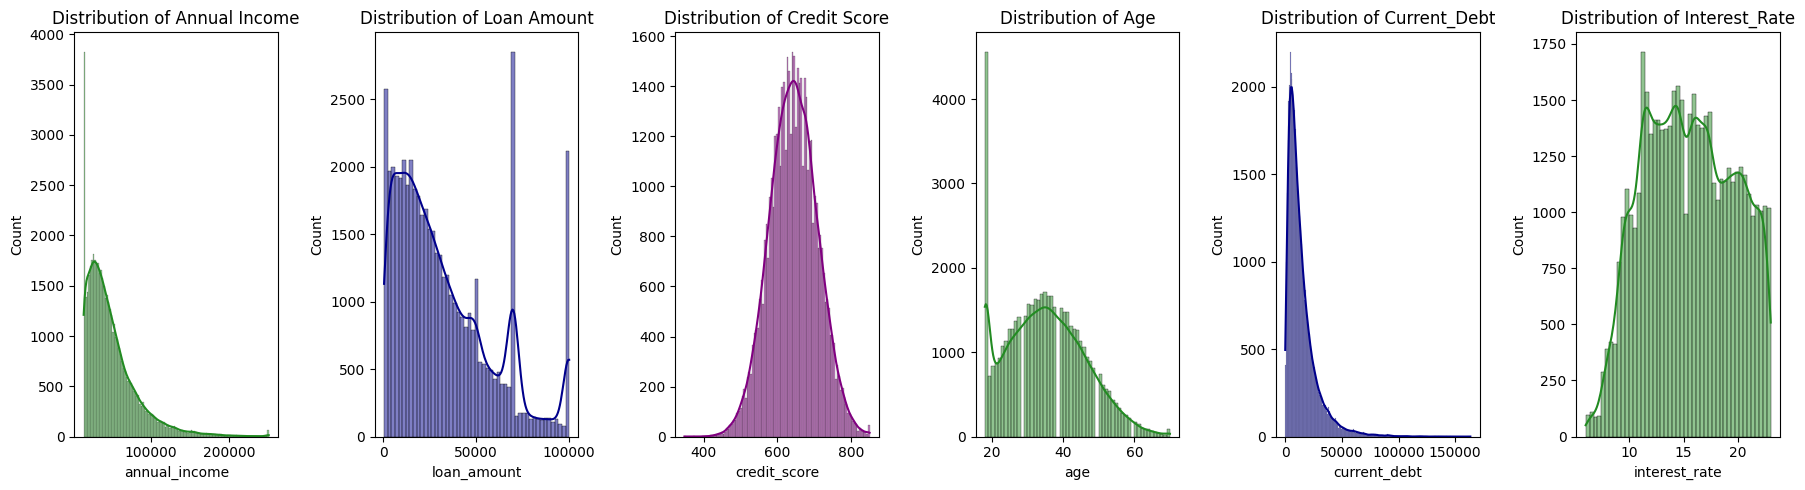

In [71]:
# The following variables annual_income, loan_amount, and credit_score will be considered.
fig, axes = plt.subplots(1, 6, figsize=(18, 5))

# Income Distribution
sns.histplot(df['annual_income'], kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Distribution of Annual Income')

# Loan Amount Distribution
sns.histplot(df['loan_amount'], kde=True, ax=axes[1], color='darkblue')
axes[1].set_title('Distribution of Loan Amount')

# Credit Score Distribution
sns.histplot(df['credit_score'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('Distribution of Credit Score')

# Age Distribution
sns.histplot(df['age'], kde=True, ax=axes[3], color='forestgreen')
axes[3].set_title('Distribution of Age')

# Current_Debt Distribution
sns.histplot(df['current_debt'], kde=True, ax=axes[4], color='darkblue')
axes[4].set_title('Distribution of Current_Debt')

# Interest_Rate Distribution
sns.histplot(df['interest_rate'], kde=True, ax=axes[5], color='forestgreen')
axes[5].set_title('Distribution of Interest_Rate')

plt.tight_layout()
plt.show()

From the distribution curves: it can be observed that credit score is a normal distribution, with a mean of 643.6 and a standard deviation 64.7. Age is slightly right-skewed but very well-behaved. The peak around 35 aligns perfectly with typical first-time homebuyer demographics in US and Canada. It is noted that there are significant young applicants (age 18) building their first credits, which was already explained in this dataset as edge Cases.

Loan Amount is right skewed, and peaked at 70,000 and 100,000. The possible reason is that applicants often request exactly the maximum amount allowed for a certain insurance bracket or down-payment tier.

Interest rate is multimodal. This usually happens when different "Risk Tiers" are assigned different fixed rates.

Annual Income and Current Debt have very long tails to the right, which means there are some applicants whose annual income and the current debt are significantly high.

### 5.3 Working with Debt_to_Income Ratio

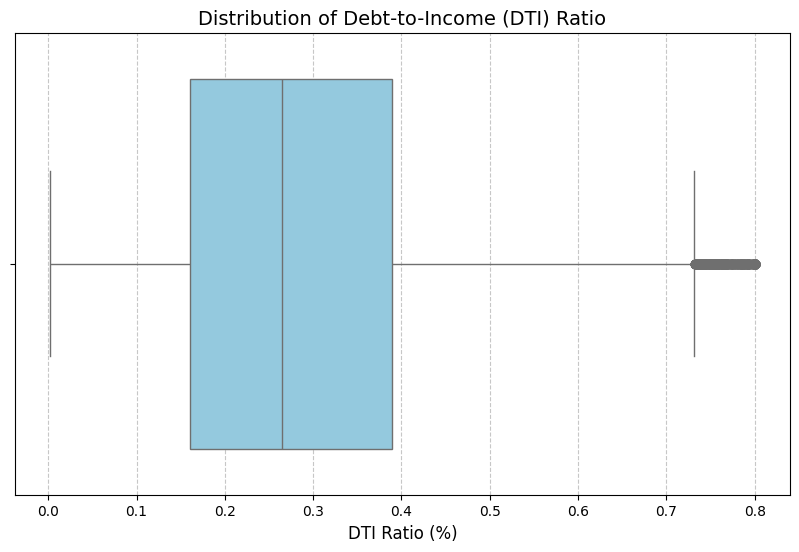

In [50]:
#1. Create box plot for debt_to_income_ratio
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['debt_to_income_ratio'], color='skyblue')

plt.title('Distribution of Debt-to-Income (DTI) Ratio', fontsize=14)
plt.xlabel('DTI Ratio (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [51]:
# 2. Calculating IQR and Flagging Outliers
Q1 = df['debt_to_income_ratio'].quantile(0.25)
Q3 = df['debt_to_income_ratio'].quantile(0.75)
IQR = Q3 - Q1

# Define typical statistical bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. CREATE THE FLAG: This adds a new column to your dataframe
# It will be 'True' if it's an outlier, 'False' if it's normal data
df['is_dti_outlier'] = (df['debt_to_income_ratio'] < lower_bound) | (df['debt_to_income_ratio'] > upper_bound)

# 4. View the results (showing only the outliers)
outlier_rows = df[df['is_dti_outlier'] == True]
print(f"Number of DTI outliers flagged: {len(outlier_rows)}")
display(outlier_rows.head())

Number of DTI outliers flagged: 332


,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,...,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status,is_dti_outlier
8,CUST100008,29,Employed,5.9,28416,569,2.6,1334,22668,1,...,0,Credit Card,Education,33800,22.72,0.798,1.189,0.396,0,True
574,CUST100574,44,Employed,0.8,33163,614,22.4,3935,24378,0,...,0,Personal Loan,Education,34000,14.14,0.735,1.025,0.342,0,True
726,CUST100726,35,Student,0.4,18392,773,4.2,1532,13692,0,...,0,Personal Loan,Home Improvement,36800,8.64,0.744,2.001,0.667,0,True
820,CUST100820,28,Employed,9.9,34197,642,6.9,4526,27357,0,...,0,Line of Credit,Personal,16700,12.99,0.800,0.488,0.163,0,True
972,CUST100972,45,Student,0.1,30170,635,15.5,420,22100,0,...,0,Personal Loan,Business,25900,14.28,0.733,0.858,0.286,0,True


### 5.4 Working with loan_to_income_ratio

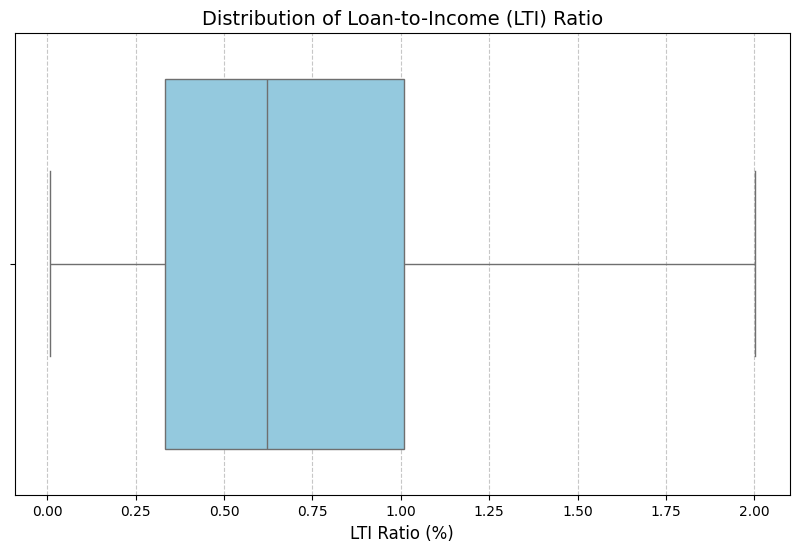

In [52]:
#1. Create box plot for loan_to_income_ratio
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['loan_to_income_ratio'], color='skyblue')

plt.title('Distribution of Loan-to-Income (LTI) Ratio', fontsize=14)
plt.xlabel('LTI Ratio (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 5.5 Working with payment_to_income_ratio

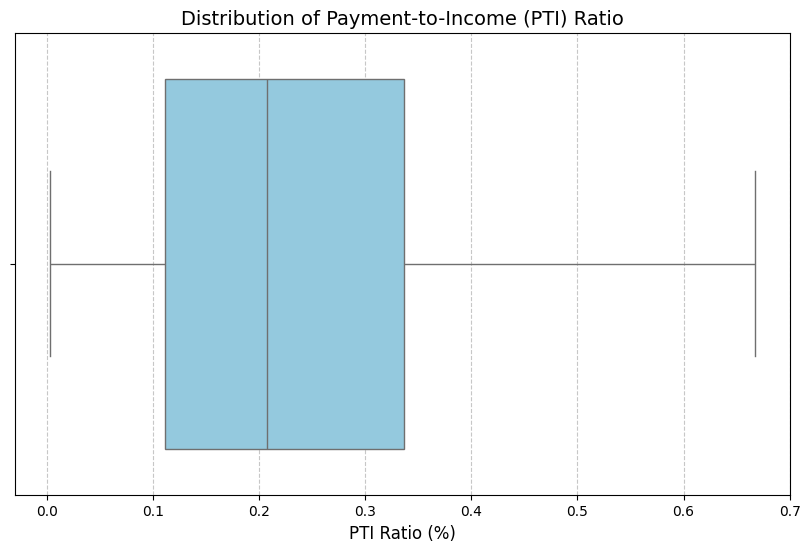

In [53]:
#1. Create box plot for payment_to_income_ratio
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['payment_to_income_ratio'], color='skyblue')

plt.title('Distribution of Payment-to-Income (PTI) Ratio', fontsize=14)
plt.xlabel('PTI Ratio (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Initial outlier detection using the 1.5x IQR method identified 332 outliers in the Debt-to-Income (DTI) ratio. Interestingly, Loan-to-Income (LTI) and Payment-to-Income (PTI) ratios showed zero outliers, suggesting a strictly enforced policy ceiling for these specific metrics in the loan approval process.

Although there is no outlier in payment_to_income_ratio, it can be observed from the box plot and the descriptive statistics that the highest PTI ratio is 0.667, which means statistically it is not an outlier, while in the real-world north American context, it is extreme. A borrower spending nearly 67% of their gross income just on their mortgage payment is considered "house poor" and under immense financial stress. From a policy perspective, this is significantly above the standard 32-39% threshold, suggesting these cases may represent specialized high-net-worth programs or non-traditional lending scenarios that warrant a separate 'Risk Flag' during feature engineering.

### 5.6 Feature Engineering: high_payment_burden

In [57]:
# Create a flag based on the common 40% threshold for financial stress
df['high_payment_burden'] = df['payment_to_income_ratio'] > 0.4

# See how many fall into this "Policy Risk" category
print(df['high_payment_burden'].value_counts())

high_payment_burden
False    41969
True      8031
Name: count, dtype: int64


In [58]:
# Check approval rates for High Burden vs. Normal Burden
approval_comparison = df.groupby('high_payment_burden')['loan_status'].value_counts(normalize=True).unstack()
print(approval_comparison)

loan_status                 0         1
high_payment_burden                    
False                0.417808  0.582192
True                 0.615365  0.384635


This outcome shows: 
Normal Group/low payment burden (False): 58% approval rate.
High Burden Group (True): 38% approval rate.
Being in the "High Payment Burden" category reduces an applicant's chance of approval by 20 percentage points (from 58% down to 38%). This proves that the payment_to_income_ratio is a very strong predictor for your future model, but it isn't a "hard stop" because nearly 4 out of 10 high-burden applicants are still getting approved.

Who are these 38% and why did they get approved despite the high risk? Is it because they had other compensating factors like a better credit score or more savings? Let's do the following exploration.

In [59]:
# Create a subset of ONLY the high-burden applicants
high_burden_df = df[df['high_payment_burden'] == True]

# Compare approved vs rejected within the high-burden group
comparison = high_burden_df.groupby('loan_status')[['credit_score', 'savings_assets']].mean()
print("Comparing Approved (1) vs Rejected (0) for High-Burden Applicants:")
print(comparison)

Comparing Approved (1) vs Rejected (0) for High-Burden Applicants:
             credit_score  savings_assets
loan_status                              
0              613.189195     1589.047552
1              684.179994     4427.024927


This outcome shows that the high-burden approved group has a much higher average credit score (684) than the rejected group, and their average savings assets is almost 3 times higher than the rejected group (4427 vs 1589), which proved our guessing. These high burden people get approved because they have other compensating factors like a better credit score and higher savings asset.

## 6. Data Analysis and Modelling

### 6.1 Feature Selection with Visual Aids

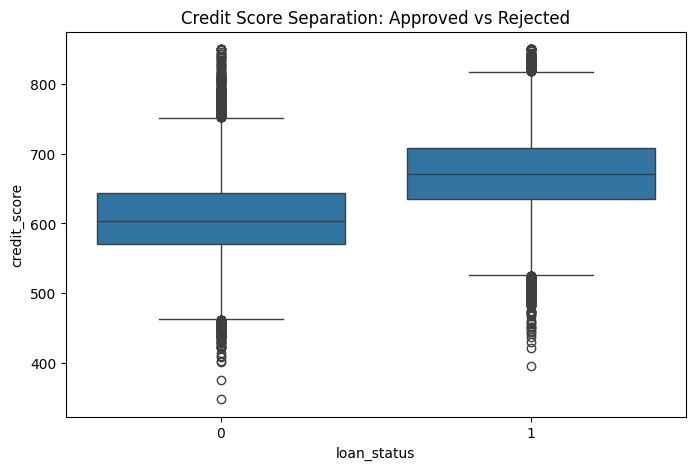

In [106]:
# Comparison of Credit Score by Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title('Credit Score Separation: Approved vs Rejected')
plt.show()

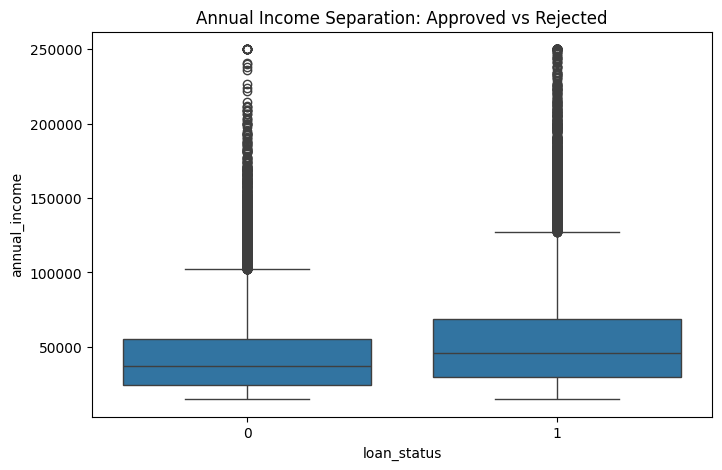

In [116]:
# Comparison of annual_income by Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='annual_income', data=df)
plt.title('Annual Income Separation: Approved vs Rejected')
plt.show()

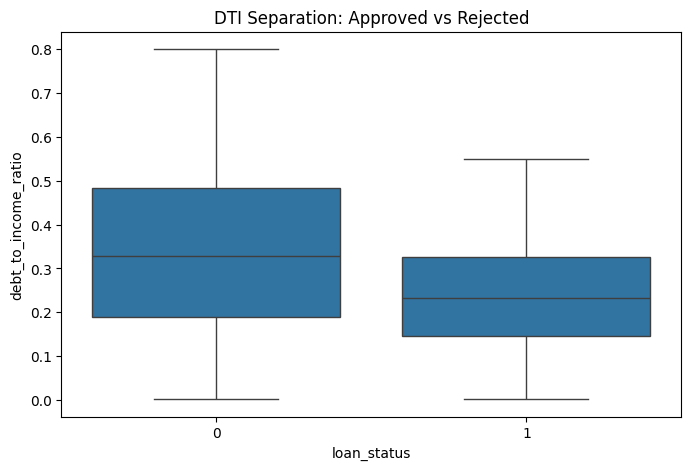

In [117]:
# Comparison of debt_to_income_ratio by Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='debt_to_income_ratio', data=df)
plt.title('DTI Separation: Approved vs Rejected')
plt.show()

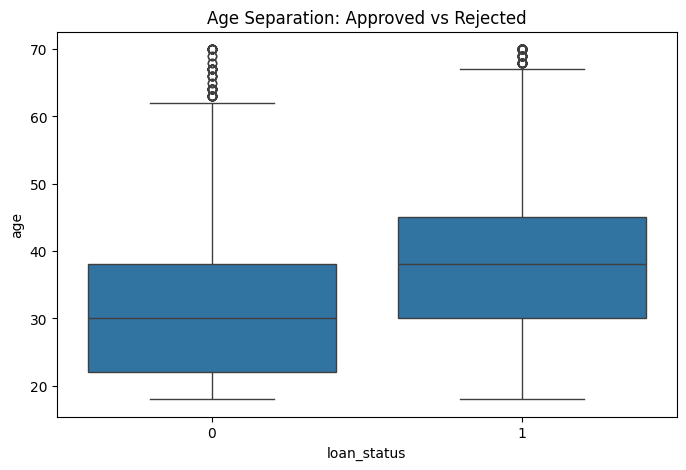

In [112]:
# Comparison of age by Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='age', data=df)
plt.title('Age Separation: Approved vs Rejected')
plt.show()

In [ ]:
# Comparison of age by Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='age', data=df)
plt.title('Age Separation: Approved vs Rejected')
plt.show()

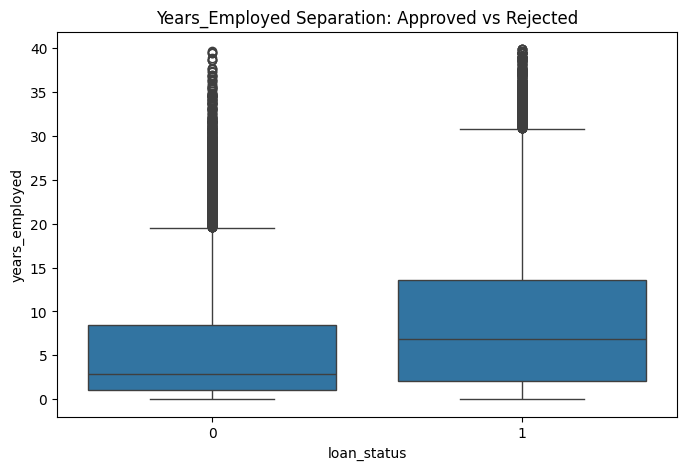

In [113]:
# Comparison of years_employed by Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='years_employed', data=df)
plt.title('Years_Employed Separation: Approved vs Rejected')
plt.show()

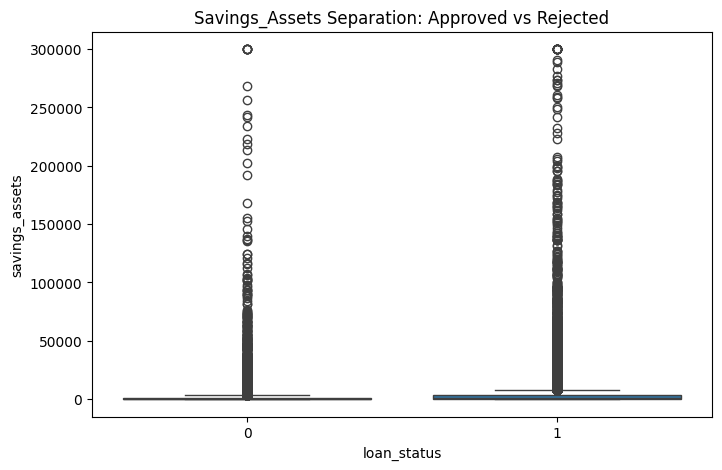

In [114]:
# Comparison of savings_assets by Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='savings_assets', data=df)
plt.title('Savings_Assets Separation: Approved vs Rejected')
plt.show()

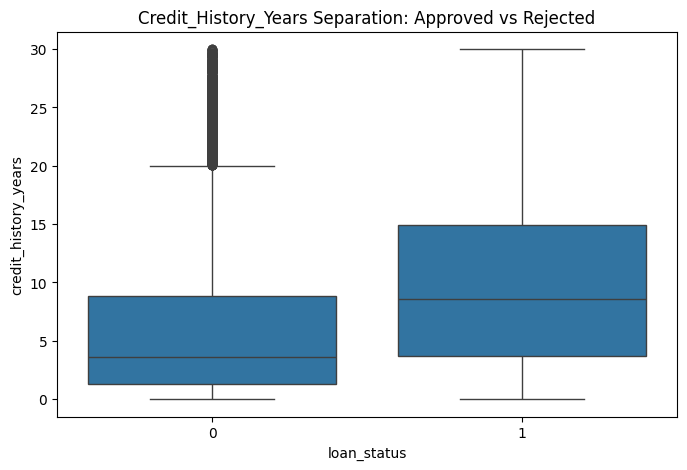

In [115]:
# Comparison of credit_history_years by Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='credit_history_years', data=df)
plt.title('Credit_History_Years Separation: Approved vs Rejected')
plt.show()

In [120]:
df[['debt_to_income_ratio', 'annual_income']].corr()

,debt_to_income_ratio,annual_income
debt_to_income_ratio,1.00000,-0.00263
annual_income,-0.00263,1.00000


In [121]:
df[['credit_score', 'credit_history_years']].corr()

,credit_score,credit_history_years
credit_score,1.000000,0.236862
credit_history_years,0.236862,1.000000


In [122]:
df[['age', 'years_employed']].corr()

,age,years_employed
age,1.00000,0.62684
years_employed,0.62684,1.00000


This part is mainly about quantitative features and the target. 7 box plots were created to explore the relationship among the quantitative features and the target. It shows credit score, debt to income ratio (DTI), annual income, age, years employed, and credit history years show great difference in the median among approved and rejected group, which means these features could be important features in predicting loan status. Then correlation coefficient between annual income and DTI, credit score and credit history years, age and years employed. The correlation coefficient between annual income and DTI is quite low, which means high income doesn't automatically mean low DTI. Credit score and credit history years are weakly-to-moderately correlated. So, introducting both could benefit the model in both the length and the quality of credit. A correlation of 0.63 between age and years employed could lead to multicollinearity in the model. Age is a demographic proxy. Years employed is a direct measure of financial stability and the ability to service a mortgage. Information Value (IV) will be used in the later part to determine which feature has a stronger predictive power.

### 6.2 Feature Selection with IV and VIF

In [138]:
# Split the dataset into Train (60%), Validation (20%), and Test (20%)

from sklearn.model_selection import train_test_split

# Define the feature list (The ones identified previously)
features = [
    'credit_score', 'debt_to_income_ratio', 'years_employed', 
    'credit_history_years', 'high_payment_burden', 
    'severe_delinquency_flag', 'has_derogatory_marks'
]

X = df[features]
y = df['loan_status']

# First split: 80% for (Train + Val) and 20% for Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Second split: From the 80%, take 25% for Validation (which is 20% of the original total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 30000 rows
Validation set: 10000 rows
Test set: 10000 rows


Please note that age is not considered as a feature in the model, as it shows medium correlation with years_employed.

In [141]:
# Define IV function
def simple_iv(df, feature, target):
    df_temp = df[[feature, target]].copy()
    
    # 1. Create Bins
    if df_temp[feature].nunique() > 10:
        df_temp['temp_bin'] = pd.qcut(df_temp[feature], 10, duplicates='drop')
    else:
        df_temp['temp_bin'] = df_temp[feature]
    
    # 2. Group and Aggregate - Added observed=True to stop the FutureWarning
    grouped = df_temp.groupby('temp_bin', observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['Total', 'Approved']
    grouped['Rejected'] = grouped['Total'] - grouped['Approved']
    
    # 3. Calculate Distributions
    # Use a tiny floor (1e-6) to ensure we never divide by zero or log zero
    dist_a = (grouped['Approved'] + 1e-6) / (grouped['Approved'].sum() + 1e-6)
    dist_r = (grouped['Rejected'] + 1e-6) / (grouped['Rejected'].sum() + 1e-6)
    
    # 4. IV Formula
    iv = ((dist_a - dist_r) * np.log(dist_a / dist_r)).sum()
    
    return iv

# Apply to the features
iv_dict = {}
for col in features:
    iv_dict[col] = simple_iv(X_train.join(y_train), col, 'loan_status')

iv_report = pd.DataFrame.from_dict(iv_dict, orient='index', columns=['IV_Score']).sort_values(by='IV_Score', ascending=False)
print(iv_report)

                         IV_Score
severe_delinquency_flag  1.677144
credit_score             1.352177
debt_to_income_ratio     0.761854
credit_history_years     0.415419
years_employed           0.274263
has_derogatory_marks     0.205775
high_payment_burden      0.085631


From the IV score, it can be seen:
* The top 3 features in the IV score ranking are severe_delinquency_flag (1.68), credit_score (1.35) and debt_to_income_ratio (0.76). severe_delinquency_flag and credit_score are heavyweights. An IV of 1.68 is massive—it suggests that a severe delinquency is almost a "perfect separator" between approval and rejection.
* Debt_to_income_ratio (0.76) and credit_history_years (0.42) are very solid. They are strong predictors.
* Years_employed (0.27) and has_derogatory_marks (0.21) are supporting features. They provide the extra nuance that catches the edge cases.
* High_payment_burden is the weakest feature, but at nearly 0.1, it is still a "Medium" predictor in many contexts.

In [142]:
# Define a function to calculate VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X_data):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X_data.columns
    vif_df["VIF"] = [variance_inflation_factor(X_data.values, i) for i in range(X_data.shape[1])]
    return vif_df.sort_values(by="VIF", ascending=False)

In [143]:
# Calculate VIF for the features

# 1. Create a list of the numeric features that need to test
vif_features = [
    'credit_score', 'debt_to_income_ratio', 'years_employed', 
    'credit_history_years', 'high_payment_burden', 
    'severe_delinquency_flag', 'has_derogatory_marks'
]

# 2. Subset the X_train to only these columns and ensure they are floats
X_vif_subset = X_train[vif_features].astype(float)

# 3. Calculate VIF
vif_results = calculate_vif(X_vif_subset)
print(vif_results)

                   Feature       VIF
0             credit_score  6.297222
1     debt_to_income_ratio  4.092010
3     credit_history_years  2.792466
2           years_employed  2.385490
4      high_payment_burden  1.190865
6     has_derogatory_marks  1.130552
5  severe_delinquency_flag  1.034682


A VIF between 1 to 2 means extremely stable, and there is no concern. Between 2 to 5 means moderate overlap with other features. When it is above 5 to 10, it shows high correlation with other feature, and the weak feature should be dropped. As credit_score shows a VIF of 6, and the previous findings shows that credit score and credit history years are weakly-to-moderately correlated, I will drop credit history years and calculate VIF again.

In [144]:
# Calculate VIF for the features

# 1. Create a list of the numeric features that need to test
vif_features = [
    'credit_score', 'debt_to_income_ratio', 'years_employed', 
     'high_payment_burden', 
    'severe_delinquency_flag', 'has_derogatory_marks'
]

# 2. Subset the X_train to only these columns and ensure they are floats
X_vif_subset = X_train[vif_features].astype(float)

# 3. Calculate VIF
vif_results = calculate_vif(X_vif_subset)
print(vif_results)

                   Feature       VIF
0             credit_score  5.502170
1     debt_to_income_ratio  4.091620
2           years_employed  2.041457
3      high_payment_burden  1.190213
5     has_derogatory_marks  1.130101
4  severe_delinquency_flag  1.034456


Although credit_score has a VIF 5.5, we should note that multicollinearity is not a big problem unless it leads to contridictory outcome to the conventional knowledge. Credit score is always an important feature for determining to approve the loan or not, so let's just keep it in the model. This model keep these 6 features: credit_score, debt_to_income_ratio, years_employed, high_payment_burden, severe_delinquency_flag, has_derogatory_marks. 

In [145]:
# Define the final 6 features
final_features = [
    'credit_score', 'debt_to_income_ratio', 'years_employed', 
     'high_payment_burden', 
    'severe_delinquency_flag', 'has_derogatory_marks'
]

X = df[final_features]
y = df['loan_status']

# First split: 80% for (Train + Val) and 20% for Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Second split: From the 80%, take 25% for Validation (which is 20% of the original total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 30000 rows
Validation set: 10000 rows
Test set: 10000 rows


### 6.3 Model Training

In [146]:
# Scaling the Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [147]:
# Train the model
from sklearn.linear_model import LogisticRegression

# Initialize and train
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Show the Coefficients (The "Influence" of each feature)
importance = pd.DataFrame({
    'Feature': final_features, 
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(importance)

                   Feature  Coefficient
0             credit_score     1.497844
2           years_employed     0.418629
5     has_derogatory_marks    -0.340219
3      high_payment_burden    -0.467829
1     debt_to_income_ratio    -1.107284
4  severe_delinquency_flag    -1.690017


This model has assigned weights that tell a very clear story about risk: 
* Positive Drivers (Approval): Credit score is the strongest predictor with the coefficient 1.50. years employed has a coefficient of 0.42. It shows that stability matters. The longer someone has been at their job, the better their chances.
* Negative Drivers (Rejection): Severe delinquency flag has the largest negative magnitude (-1.69), which shows the model has successfully identified this as a "Hard Stop" for lenders. Then it is debt to incom ratio with the magnitude -1.1. High debt relative to income is a primary reason for rejection. High payment burden (-0.47) and has derogatory marks (-0.34) add incremental risk. They are less powerful than a severe delinquency but still provide a significant downward push on the approval probability.

### 6.4 Model Validation

Validation Set Performance:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78      4496
           1       0.81      0.84      0.83      5504

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



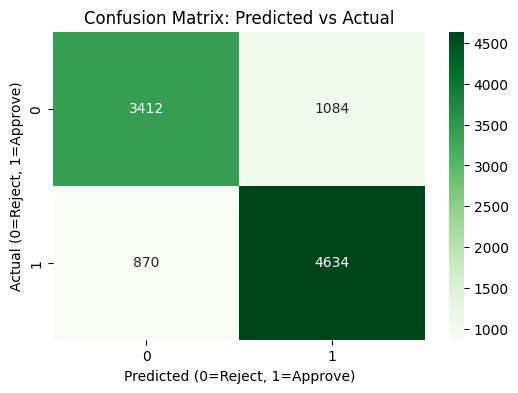

In [149]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Get predictions on the Scaled Validation set
y_pred_val = log_reg.predict(X_val_scaled)

# 2. Print the Report
print("Validation Set Performance:")
print(classification_report(y_val, y_pred_val))

# 3. Visualizing the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, y_pred_val), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted (0=Reject, 1=Approve)')
plt.ylabel('Actual (0=Reject, 1=Approve)')
plt.show()

The performance shows:
* An accuracy of 0.80 and balanced F1-scores (0.78 for rejections, 0.83 for approvals) indicate that the model performs consistently across both outcomes.
* Recall for rejections is 0.76. The model successfully identifies 76% of high-risk applicants who should be rejected.
* Recall for approvals is 0.84. The model captures 84% of the good candidates. This means the model is "business-friendly"—it doesn't leave too many good loans on the table. 

For the confusion matrix:
Among 10,000 validation samples:
* True Negatives (3412): Correctly identified high-risk applicants.
* True Positives (4634): Correctly identified safe-bet approvals.
* False Positives (1084): These are the "Risky Approvals." The model said yes, but the actual ground truth was no.
* False Negatives (870): These are the "Missed Opportunities." The model said no, but they were actually good candidates.

### 6.5 Test the Model with the Test Data

--- FINAL UNBIASED TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.79      0.75      0.77      4495
           1       0.80      0.84      0.82      5505

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



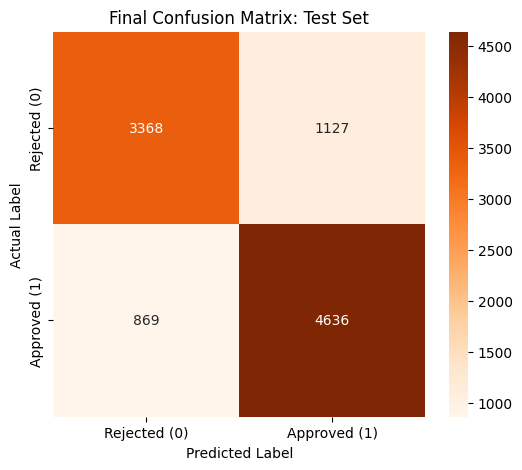

In [150]:
# 1. Predict using the scaled Test set (the data the model has never seen)
y_pred_test = log_reg.predict(X_test_scaled)

# 2. Final Classification Report
print("--- FINAL UNBIASED TEST SET PERFORMANCE ---")
print(classification_report(y_test, y_pred_test))

# 3. Final Confusion Matrix visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.title('Final Confusion Matrix: Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

The performance of the test data shows:
* An accuracy of 0.80 which is the same with the validatation data. Balanced F1-scores (0.77 for rejections, 0.82 for approvals) which is only 1% different from the validation data respectively. It proves that the model is robust and generalizable. It didn't just memorize the training data; it successfully captured the underlying logic of credit risk that applies to new, unseen applicants.
* Comparing the confusion matrices between the validation and test datasets proves the stability of the model, as they look nearly identical, which again proves that the model hasn't just memorized a specific subset of data, but has truly learned the underlying laws of the dataset.

### 6.6 Creating the ROC Curve

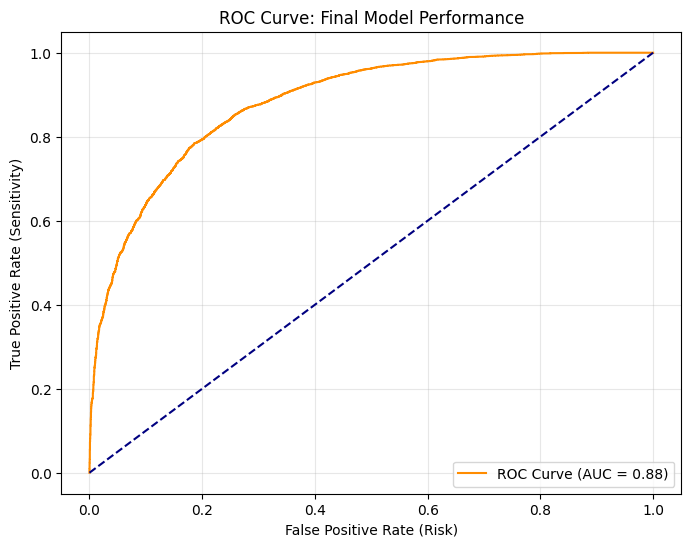

In [152]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Get the probabilities instead of just 0 or 1
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 3. Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate (Risk)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve: Final Model Performance')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

An AUC of 0.5 is as good as a coin flip. 0.7 to 0.8 is considered good. 0.8 to 0.9 is excellent. This model shows an AUC of 0.88 which means the model is excellent. It indicates that there is an 88% chance that the model will be able to distinguish between a good applicant and a bad applicant correctly.



### 6.7 Model Transparency & Sample Predictions

In [157]:
# 1. Get the probability of approval (Class 1) for the first 5 people in the test set
sample_probs = log_reg.predict_proba(X_test_scaled[:5])[:, 1]
sample_preds = y_pred_test[:5]

# 2. Create a clean look at the "Risk Scores"
sample_summary = pd.DataFrame({
    'Actual_Status': y_test[:5].values,
    'Model_Prediction': sample_preds,
    'Approval_Probability': [f"{p:.2%}" for p in sample_probs]
})

print("Sample Probability Audit:")
print(sample_summary)

Sample Probability Audit:
   Actual_Status  Model_Prediction Approval_Probability
0              0                 0               13.88%
1              0                 0               14.32%
2              1                 1               98.46%
3              0                 0                1.99%
4              0                 0               45.13%


### 6.8 Model Summary

This model uses 6 features: credit_score, debt_to_income_ratio, years_employed, high_payment_burden, severe_delinquency_flag, has_derogatory_marks to predict loan status. Severe delinquency flag has the largest magnitude in the negative direction(-1.69), which is identified as a hard stop for lenders. Credit score is the second strongest predictor, and its impact is in the positive direction (1.50). Debt_to_income_ratio is the third strongest predictor and its impact is in the negative direction (-1.1).

Model Performance:
* Final Test Accuracy: 80%
* Area Under the Curve (AUC): The AUC of 0.88 indicates excellent ability to distinguish between "Good" and "Bad" credit risks.
* Robustness: The negligible variance (<1%) between Validation and Test set confusion matrices confirms the model's robustness and lack of overfitting.

### 6.9 Sensitivity Analysis

When the inflation rate increases or there is a rate hike, a borrower's monthly debt payments increase. Since income stays the same, their Debt-to-Income (DTI) ratio goes up. I will consider two different scenarios for this factor. The first is average DTI increases by 10%. The second is by 20%.

In [155]:
# 1. Create a "Stressed" version of your test data
X_test_stressed = X_test.copy()

# Scenario: Average DTI increases by 10% (Inflation/Rate Hike)
X_test_stressed['debt_to_income_ratio'] = X_test_stressed['debt_to_income_ratio'] * 1.1

# 2. Re-Scale the stressed data using the SAME scaler from earlier
X_test_stressed_scaled = scaler.transform(X_test_stressed)

# 3. Predict using the same trained model
y_pred_stressed = log_reg.predict(X_test_stressed_scaled)

# 4. Compare Approval Rates
original_approval_rate = y_pred_test.mean()
stressed_approval_rate = y_pred_stressed.mean()

print(f"Original Approval Rate: {original_approval_rate:.2%}")
print(f"Stressed Approval Rate: {stressed_approval_rate:.2%}")
print(f"Impact: {stressed_approval_rate - original_approval_rate:.2%}")

Original Approval Rate: 57.63%
Stressed Approval Rate: 53.74%
Impact: -3.89%


In [156]:
# 1. Create a "Stressed" version of your test data
X_test_stressed = X_test.copy()

# Scenario: Average DTI increases by 20% (Inflation/Rate Hike)
X_test_stressed['debt_to_income_ratio'] = X_test_stressed['debt_to_income_ratio'] * 1.2

# 2. Re-Scale the stressed data using the SAME scaler from earlier
X_test_stressed_scaled = scaler.transform(X_test_stressed)

# 3. Predict using the same trained model
y_pred_stressed = log_reg.predict(X_test_stressed_scaled)

# 4. Compare Approval Rates
original_approval_rate = y_pred_test.mean()
stressed_approval_rate = y_pred_stressed.mean()

print(f"Original Approval Rate: {original_approval_rate:.2%}")
print(f"Stressed Approval Rate: {stressed_approval_rate:.2%}")
print(f"Impact: {stressed_approval_rate - original_approval_rate:.2%}")

Original Approval Rate: 57.63%
Stressed Approval Rate: 50.44%
Impact: -7.19%


It shows that when average DTI increases by 10%, the approval rate is dropped by 3.89% from 57.63% to 53.74%, and when the average DTI increases by 20%, the approval rate is dropped by 7.19% from 57.63% to 50.44%. This shows a linear logic, which means the model has a very stable and predictable response curve.

The model is Economically Aware. If debt burdens increase (due to interest rate hikes or inflation), the model automatically tightens its lending standards to protect the institution's capital.

## 7. Conclusion

This project successfully developed a high-performing predictive model for credit risk assessment. By utilizing a rigorous feature selection process (IV and VIF), the model achieved a 0.88 AUC, demonstrating excellent discriminatory power. The alignment between validation and test results confirms that the model is robust, generalizable, and free from overfitting. It provides a data-driven foundation for automating loan approvals while maintaining strict institutional risk standards.

## 8. Policy Recommendations

Based on the model performance and sensitivity analysis, the following actions are recommended:
* Dynamic Thresholding: Use the 0.88 AUC to set tiered approval categories. For example, "Green-light" applicants with a probability > 80%, and flag Gray-area applicants (50%-70%) for manual human review.
* Risk-Based Pricing: Utilize the model's probability scores to adjust interest rates. Higher-risk applicants (as identified by the model) could be offered loans with higher premiums to offset potential losses.
* Economic "Trip-Wires": Based on the Stress Test results, the institution should implement a policy to automatically tighten the model's approval threshold if the national average DTI rises by more than 10%.

## References:

* Patel, P. (2024). Realistic Loan Approval Dataset | US & Canada. Kaggle. https://www.kaggle.com/datasets/parthpatel2130/realistic-loan-approval-dataset-us-and-canada/discussion/642455
* Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research.
* Pandas Development Team. (2026). Pandas: Powerful data analysis toolkit. https://pandas.pydata.org/
* Canada Mortgage and Housing Corporation (CMHC). (2025). Mortgage Insurance Underwriting Policy & Debt Service Ratios. [Reference for the GDS/TDS standards] https://www.cmhc-schl.gc.ca/professionals/project-funding-and-mortgage-financing/mortgage-loan-insurance/mortgage-loan-insurance-homeownership-programs/purchase?ap=a1-p1
* Government of Canada. Residential Mortgage Underwriting Practices and Procedures (Guideline B-20). Office of the Superintendent of Financial Institutions (OSFI). https://www.osfi-bsif.gc.ca/en/guidance/guidance-library/final-revised-guideline-b-20-residential-mortgage-underwriting-practices-procedures
* Li, X., & Li, J. (2025). Exploring Factors Involved in Loan Approval Decision: Deep Insights and Data Analytics Techniques. IEEE Access. https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=11205500